100%|██████████| 9.91M/9.91M [00:07<00:00, 1.39MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 226kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 638kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 822kB/s]
C:\Users\a1921\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\a1921\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\a1921\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\a1921\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: 

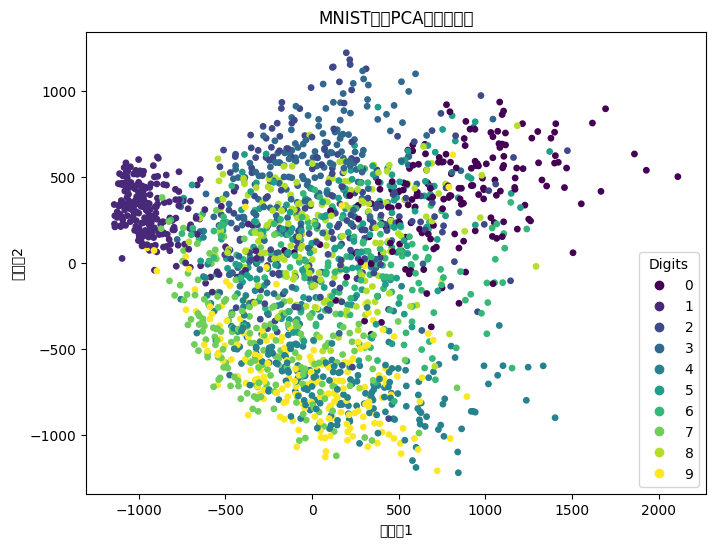

In [1]:
"""
1. 数据预处理：对MNIST图像数据进行展平（将28×28的二维图像转换成784维向量），并进行标准化。
2. 计算协方差矩阵，通过样本均值归一化后的数据构造协方差矩阵。
3. 对协方差矩阵进行特征值分解，选取前 k 个特征向量构成投影矩阵。
4. 将原始数据投影到低维空间，得到降维结果。
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torchvision import datasets, transforms

# 下载MNIST数据集（这里只使用测试集的一部分）
transform = transforms.Compose([transforms.ToTensor()])
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 提取部分数据进行试验：例如选择前2000个样本证明算法思路
num_samples = 2000
data = mnist_test.data[:num_samples].numpy().reshape(num_samples, -1).astype(np.float32)
labels = mnist_test.targets[:num_samples].numpy()

# 数据标准化：扣除均值，使得每个特征的均值为0
data_mean = np.mean(data, axis=0)
data_centered = data - data_mean

# PCA降维至二维
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_centered)

# 可视化结果（二维散点图）
plt.figure(figsize=(8,6))
# 分别取第一主成分和第二主成分作为x/y坐标
scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels, cmap='viridis', s=15)
plt.legend(*scatter.legend_elements(), title="Digits")
plt.title("MNIST数据PCA降维到二维")
plt.xlabel("主成分1")
plt.ylabel("主成分2")
plt.show()